<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/LIVERPOOL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
import math
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

#Liverpool

In [74]:
#Obtener datos
df = yf.download('LIVEPOL1.MX', start='2024-01-01', end ='2026-06-26')

/tmp/ipykernel_3221/2057216176.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('LIVEPOL1.MX', start='2024-01-01', end ='2026-06-26')
[*********************100%***********************]  1 of 1 completed


In [75]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [76]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [77]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

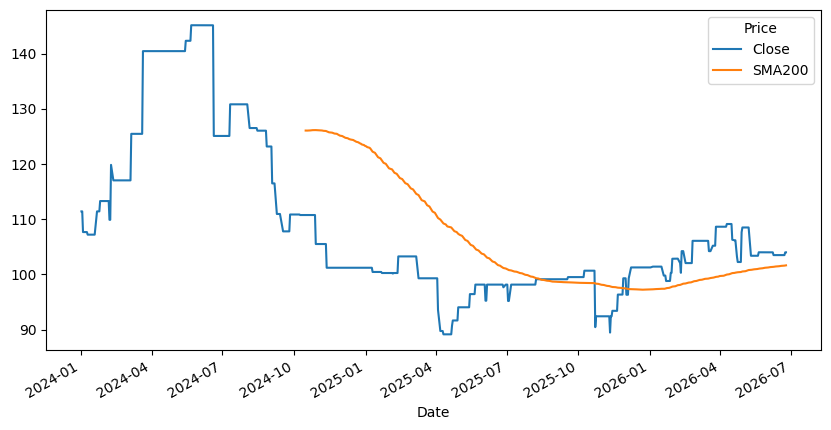

In [78]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [79]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [80]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

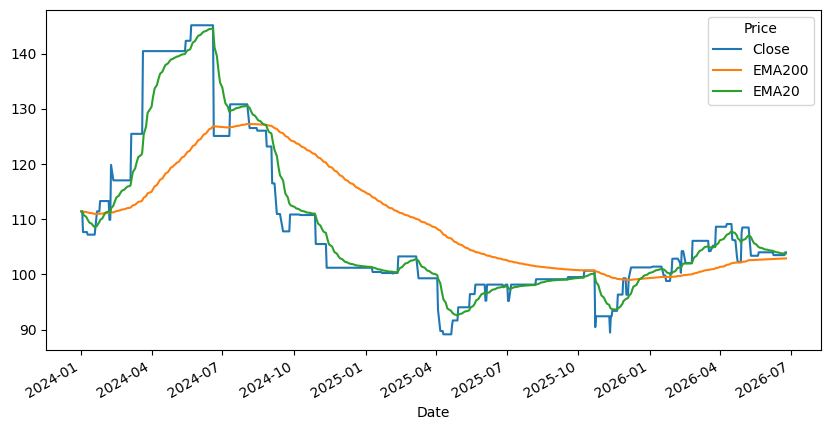

In [81]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

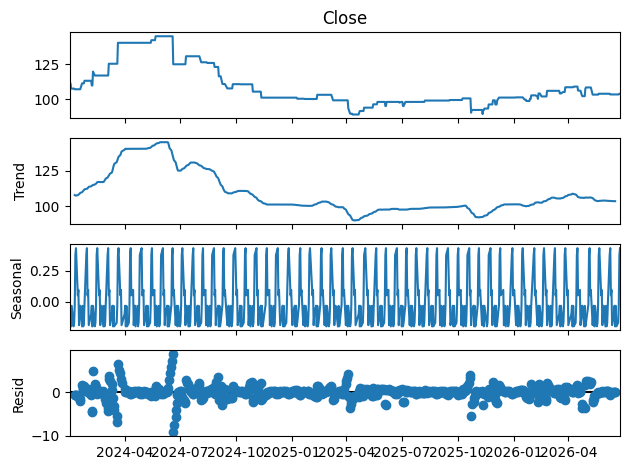

In [82]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

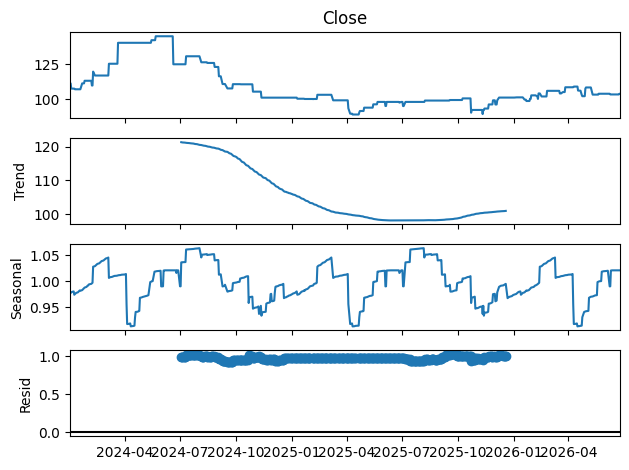

In [83]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

#Volatilidad

##Desviación Estándar

In [84]:
#Obtener datos
precios = df['Close']

In [85]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
                ...   
2026-06-19    0.000000
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.004819
2026-06-25    0.000000
Name: Rendimientos_Log, Length: 621, dtype: float64


In [86]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03    0.000000
2024-01-04   -0.034191
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-06-19    0.000000
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.004819
2026-06-25    0.000000
Name: Rendimientos_Log, Length: 620, dtype: float64


In [87]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()
print(f"Volatilidad diaria: {volatilidad_diaria:.4f}")

Volatilidad diaria: 0.0135


In [88]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)
print(f"Volatilidad anualizada: {volatilidad_anual:.4f}")

Volatilidad anualizada: 0.2138


In [89]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [90]:
print(f"Volatilidad diaria: {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 1.3465 %
Volatilidad anualizada: 21.3752 %


##Average True Range

In [91]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [92]:
print(high_low)

Date
2024-01-03    0.0
2024-01-04    0.0
2024-01-05    0.0
2024-01-08    0.0
2024-01-09    0.0
             ... 
2026-06-19    0.0
2026-06-22    0.0
2026-06-23    0.0
2026-06-24    0.0
2026-06-25    0.0
Length: 620, dtype: float64


In [93]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    3.745102
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-06-19    0.000000
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.500000
2026-06-25    0.000000
Length: 620, dtype: float64


In [94]:
print(low_close)

Date
2024-01-03         NaN
2024-01-04    3.745102
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-06-19    0.000000
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.500000
2026-06-25    0.000000
Length: 620, dtype: float64


In [95]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [96]:
print(true_range)

Date
2024-01-03    0.000000
2024-01-04    3.745102
2024-01-05    0.000000
2024-01-08    0.000000
2024-01-09    0.000000
                ...   
2026-06-19    0.000000
2026-06-22    0.000000
2026-06-23    0.000000
2026-06-24    0.500000
2026-06-25    0.000000
Length: 620, dtype: float64


In [97]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [98]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [99]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price        High    Low  Close  ATR_Calculado
Date                                          
2026-06-19  103.5  103.5  103.5       0.152213
2026-06-22  103.5  103.5  103.5       0.141341
2026-06-23  103.5  103.5  103.5       0.131245
2026-06-24  104.0  104.0  104.0       0.157584
2026-06-25  104.0  104.0  104.0       0.146328


In [100]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: ${atr_diario:.4f}")

ATR diario: $0.4167


In [101]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: ${atr_anualizado:.4f}")

ATR anualizado: $6.6147


In [102]:
# Obtener el último precio de cierre (el del 26/06/26)
precio_cierre_final = df['Close'].iloc[-1]
print("El último precio de cierre es: $", precio_cierre_final)

El último precio de cierre es: $ 104.0


In [103]:
#Convertimos en porcentaje ya que lo anterior es calculado con precios de cierre
ATR_diario_porcentaje = (atr_diario/precio_cierre_final) * 100
ATR_anualizado_porcentaje = (atr_anualizado/precio_cierre_final) * 100

In [104]:
print(f"ATR diario: {ATR_diario_porcentaje:.4f} %")
print(f"ATR anualizado: {ATR_anualizado_porcentaje:.4f} %")

ATR diario: 0.4007 %
ATR anualizado: 6.3603 %


#Parámetros (p,d,q)

##Estacionariedad

###Prueba Dickey Fuller

In [105]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [106]:
#Obtener datos precios de cierre originales
precios = df['Close']

In [107]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: -1.3283
Valor p: 0.6161
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.6161192181302073)

In [108]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada) a los rendimientos logarítmicos
probar_estacionariedad(df['Rendimientos_Log'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: -25.2911
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

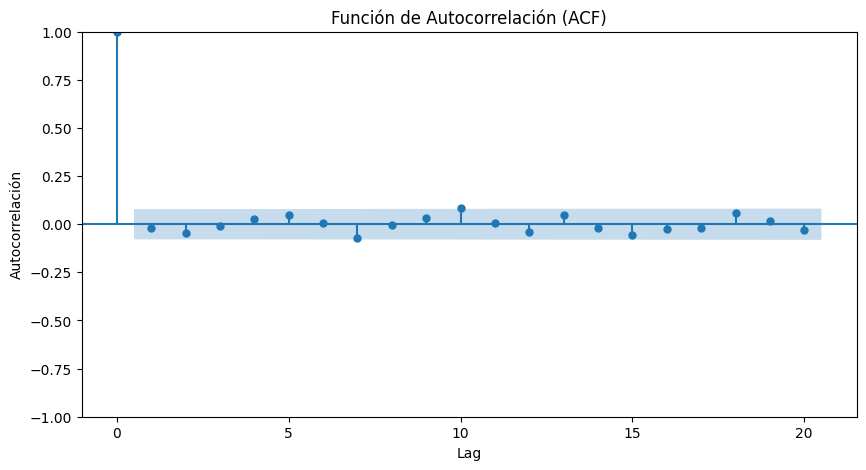

In [109]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

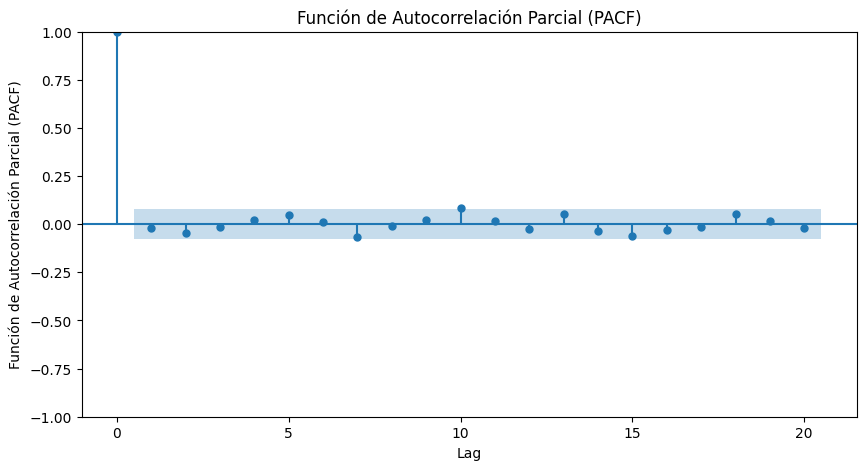

In [110]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()